# Pre trained infer

加载前需要进行更改
  1. 下载ntv3_base_model，并将modeling_ntv3_pretrained.py，tokenization_ntv3.py，configuration_ntv3_pretrained.py复制到对应文件夹中
  2. 更改tokenizer_config.json中"auto_map"为"AutoTokenizer": ["tokenization_ntv3.NTv3Tokenizer", null]
  3. 更改config.json "auto_map"为
     {
        "AutoConfig": "configuration_ntv3_pretrained.Ntv3PreTrainedConfig",
        "AutoModelForMaskedLM": "modeling_ntv3_pretrained.NTv3PreTrained"
      }
  5. 更改modeling_ntv3_pretrained.py中import类，仅保留from .configuration_ntv3_pretrained import Ntv3PreTrainedConfig

In [1]:
from Bio import SeqIO
from transformers import AutoConfig, AutoModelForMaskedLM, AutoTokenizer
import torch

/root/peaks2/.pixi/envs/training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# init
model_path = "./weight/NTV3_8M_pre"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
config = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForMaskedLM.from_pretrained(model_path, config=config, trust_remote_code=True)

model.to(device)

NTv3PreTrained(
  (core): Core(
    (embed_layer): Embedding(11, 16)
    (stem): Stem(
      (conv): Conv1d(16, 256, kernel_size=(15,), stride=(1,), padding=same)
    )
    (conv_tower_blocks): ModuleList(
      (0-6): 7 x ConvTowerBlock(
        (conv): ConvBlock(
          (conv): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=same)
          (layer_norm): LayerNormFP32((np.int64(256),), eps=1e-05, elementwise_affine=True)
        )
        (res_conv): ResidualConvBlock(
          (conv_block): ConvBlock(
            (conv): Conv1d(256, 256, kernel_size=(1,), stride=(1,), padding=same)
            (layer_norm): LayerNormFP32((np.int64(256),), eps=1e-05, elementwise_affine=True)
          )
        )
        (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      )
    )
    (transformer_blocks): ModuleList(
      (0-1): 2 x SelfAttentionBlock(
        (self_attention_layer_norm): LayerNormFP32((256,), eps=1e-05, elementwise_affine=True)
        (final_layer_

In [21]:
genomeseq_dict = SeqIO.to_dict(SeqIO.parse("./data/A157.chr.fa", "fasta"))

In [25]:
seq = genomeseq_dict['A157_chr01'].seq[182095 - 12800:182095 + 12800]

In [37]:
tokens = tokenizer(str(seq), padding="max_length", truncation=True, max_length=25600, return_tensors="pt",)
tokens = tokens["input_ids"][0]

tensor([7, 6, 7,  ..., 9, 8, 6], device='cuda:0')

In [47]:
embeddings = model(input_ids=tokens.to(device).unsqueeze(0), output_hidden_states=True)

In [54]:
embeddings.hidden_states[-1].shape

torch.Size([1, 25600, 256])

# Data

In [2]:
from model.dataset import GenomeBigWigDataset
from model.utils import transform_fn, load_Data
import pandas as pd
import os
import pathlib
import pyfaidx
from transformers import AutoConfig, AutoModelForMaskedLM, AutoTokenizer
import torch
from torch.utils.data import DataLoader
import toml
import time

def load_config(config_path: str):
    with open(config_path, "r") as f:
        config = toml.load(f)
    return config

tokenizer = AutoTokenizer.from_pretrained("/root/peaks2/NTv3/weight/NTV3_8M_pre")

config = load_config("config/fineturn_my.toml")
print(config)

faidx = pyfaidx.Fasta(config["fasta_path"])
gene_bed = os.path.join(config["training_data_dir"], config["gene_bed"])
gene_bed = pd.read_csv(gene_bed, sep="\t", header=None, names=["chrom", "start", "end", "id", "type"])
gene_bed = load_Data(gene_bed, faidx, config["TSS_up"], config["TSS_down"])
faidx.close()

train_dataset = GenomeBigWigDataset(
    fasta_path="/vepfs-C/vepfs_public/daijc/lncRNA/training_data/A157.fa",
    bigwig_path_list=[os.path.join(config["training_data_dir"], f) for f in config["bigwig_files"]],
    chrom_regions = gene_bed,
    sequence_length=config["sequence_length"],
    tokenizer=tokenizer,
    transform_fn = transform_fn,
    keep_target_center_fraction=0.5,
    num_samples=len(gene_bed)
)

# for batch in DataLoader(train_dataset, batch_size=16, num_workers=4, prefetch_factor=2):
#     # print(batch)
#     i += 1
#     print(batch['tokens'].shape)
#     print(f"batch {i}: {time.time()}")
#     if i == 5:
#         break

/root/peaks2/.pixi/envs/training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'model_name': '/root/peaks2/NTv3/weight/NTV3_100M_pre', 'fasta_path': '/vepfs-C/vepfs_public/daijc/lncRNA/training_data/A157.fa', 'TSS_up': 3000, 'TSS_down': 3000, 'sequence_length': 6000, 'keep_target_center_fraction': 0.5, 'num_tracks': 54, 'training_data_dir': '/vepfs-C/vepfs_public/daijc/lncRNA/training_data', 'gene_bed': 'merged_combined_sorted.bed', 'bigwig_files': ['C3-1_sort.h5', 'C3-2_sort.h5', 'C3-3_sort.h5', 'C6-1_sort.h5', 'C6-2_sort.h5', 'C6-3_sort.h5', 'C12-1_sort.h5', 'C12-2_sort.h5', 'C12-3_sort.h5', 'C24-1_sort.h5', 'C24-2_sort.h5', 'C24-3_sort.h5', 'C36-1_sort.h5', 'C36-2_sort.h5', 'C36-3_sort.h5', 'C48-1_sort.h5', 'C48-2_sort.h5', 'C48-3_sort.h5', 'T3-1_sort.h5', 'T3-2_sort.h5', 'T3-3_sort.h5', 'T6-1_sort.h5', 'T6-2_sort.h5', 'T6-3_sort.h5', 'T12-1_sort.h5', 'T12-2_sort.h5', 'T12-3_sort.h5', 'T24-1_sort.h5', 'T24-2_sort.h5', 'T24-3_sort.h5', 'T36-1_sort.h5', 'T36-2_sort.h5', 'T36-3_sort.h5', 'T48-1_sort.h5', 'T48-2_sort.h5', 'T48-3_sort.h5', 'flower-1_sort.h5', 'flo

# Detach pre-trained model

In [1]:
from model.head import HFModelWithHead_Infer
from pytorch_lightning import seed_everything

import torch
from torch import nn
from transformers import AutoConfig, AutoModelForMaskedLM, AutoTokenizer

import toml
from typing import Dict, Tuple
import pyfaidx
import os
import pandas as pd
import numpy as np

def load_config(config_path: str) -> Dict:
    with open(config_path, "r") as f:
        config = toml.load(f)
    return config

def init_config(config: Dict) -> Dict:
    # Set random seed
    seed_everything(config["seed"], workers=True)
    # device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    config["device"] = device

    return config

def init_model(config: Dict) -> Tuple[nn.Module, AutoTokenizer]:
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(config["model_name"], trust_remote_code=True)
    # Create model
    model = HFModelWithHead_Infer(
        model_name=config["model_name"],
        num_tracks=config["num_tracks"],
        keep_target_center_fraction=config["keep_target_center_fraction"],
    )

    return model, tokenizer

def load_ckpt_with_compile(
    my_models: nn.Module, 
    ckpt_path: str, 
    device: str = "cuda", 
    prefix_in_lightning: str = "mymodel.",
    compile: bool = False,
    strict: bool = True,
):
    """Load checkpoint.

    Args:
        my_models (pl.LightningModule): pl.LightningModule to load checkpoint.
        ckpt_path (str): Checkpoint path.
        device (str, optional): Device to load checkpoint. Defaults to "cuda".
        prefix_in_lightning (str, optional): Prefix in Lightning checkpoint. Defaults to "mymodel.".
        compile (bool, optional): Whether to compile model. Defaults to False.
        strict (bool, optional): Whether to strictly load state_dict (for RoPE cache, False). Defaults to True.

    Return:
        my_models: Loaded model for eval
    """
    checkpoint = torch.load(ckpt_path, map_location=device)  # 或 "cuda" if GPU

    # 2. 提取 state_dict（注意：Lightning 保存的 key 带有 "model." 前缀）
    state_dict = checkpoint["state_dict"]

    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        if k.startswith(prefix_in_lightning):
            new_k = k[len(prefix_in_lightning):]  # 去掉 "model." 前缀
            if compile: 
                if "_orig_mod." in new_k: # 模型训练过程中使用torch.compile会在ckpt的权重文件中增加_orig_mod 需要去掉 否则无法加载
                    new_k = new_k.replace("_orig_mod.", "")
                
            new_state_dict[new_k] = v
        else:
            # 可能还有其他非 model 的参数（如 loss_fn 等），跳过
            continue

    # 4. 加载到 my_models（纯 nn.Module）
    my_models.load_state_dict(new_state_dict, strict=strict)

    return my_models

config = load_config("config/fineturn_my.toml")
model, tokenizer = init_model(config)

# load ckpt
device = "cuda:1"
ckpt_path = "/vepfs-C/vepfs_public/daijc/lncRNA/checkpoints/NTv3-pre-100M_fineturn_6k_epcho71-val_pcc0.5.ckpt"
model = load_ckpt_with_compile(model, ckpt_path, device, compile=True, strict=False)
model = model.to(device)
model.eval()


/root/peaks2/.pixi/envs/training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HFModelWithHead_Infer(
  (backbone): NTv3PreTrained(
    (core): Core(
      (embed_layer): Embedding(11, 16)
      (stem): Stem(
        (conv): Conv1d(16, 768, kernel_size=(15,), stride=(1,), padding=same)
      )
      (conv_tower_blocks): ModuleList(
        (0-6): 7 x ConvTowerBlock(
          (conv): ConvBlock(
            (conv): Conv1d(768, 768, kernel_size=(5,), stride=(1,), padding=same)
            (layer_norm): LayerNormFP32((np.int64(768),), eps=1e-05, elementwise_affine=True)
          )
          (res_conv): ResidualConvBlock(
            (conv_block): ConvBlock(
              (conv): Conv1d(768, 768, kernel_size=(1,), stride=(1,), padding=same)
              (layer_norm): LayerNormFP32((np.int64(768),), eps=1e-05, elementwise_affine=True)
            )
          )
          (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
        )
      )
      (transformer_blocks): ModuleList(
        (0-5): 6 x SelfAttentionBlock(
          (self_attention_layer_nor

## Nucleotide dependencies

基因的TSS上下游2000 bp区域内进行预测，对每个位点突变为其他的三个碱基，分别计算其对应的logit score

因此此处的设计是每次计算一个基因的上下游区域，每个区域内的每个位点都进行预测，最后将所有的结果合并起来

GenomeBigWigDataset_Nucl_Depend的输入仅依赖于一个区域 生成的dataset全是突变后的结果 1 + 2000 * 3 = 6001个序列

In [36]:
from model.dataset import GenomeBigWigDataset_Nucl_Depend
from model.utils import load_Data, transform_fn
from model.decorator import NUC_CONFIG
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.amp.autocast_mode import autocast
from tqdm import tqdm

TSS_UP, TSS_DOWN = (1500, 500)
NUC_TAB = NUC_CONFIG.NUC_TAB
ACGT_IDX = NUC_CONFIG.ACGT_IDX

def Infer_for_Nucleotide_dependencies(model, infer_dataloader, device):
    output_arrays = []
    for idx, batch in enumerate(
        tqdm(
            infer_dataloader, 
            desc="Processing batches", 
            total=len(infer_dataloader)
        )
    ):

        tokens = batch["tokens"].to(device)

        with autocast(device_type="cuda", dtype=torch.float32):
            with torch.no_grad():
                outputs = model(tokens, return_dict=True)

        output_probs = F.softmax(outputs['logits'], dim=-1)[:, :(TSS_UP+TSS_DOWN), ACGT_IDX]
        output_arrays.append(output_probs) 

    snp_reconstruct = torch.concat(output_arrays, axis=0)
    snp_reconstruct.detach().cpu().to(torch.float32).numpy()

    return snp_reconstruct

faidx = pyfaidx.Fasta(config["fasta_path"])
gene_bed = os.path.join(config["training_data_dir"], config["gene_bed"])
gene_bed = pd.read_csv(gene_bed, sep="\t", header=None, names=["chrom", "start", "end", "id", "type"])
gene_bed = load_Data(gene_bed, faidx, TSS_UP, TSS_DOWN) # TSS up 1500, TSS down 500
faidx.close()

# 随机打乱gene bed
gene_bed = gene_bed.sample(frac=1, random_state=123).reset_index(drop=True)
infer_bed = gene_bed.iloc[1]
chrom_dict = {
    'chrom': infer_bed['chrom'],
    'start': infer_bed['region_start'],
    'end': infer_bed['region_end'],
}

# dataset
infer_dataset = GenomeBigWigDataset_Nucl_Depend(
    fasta_path=config["fasta_path"],
    chrom_regions=chrom_dict,
    sequence_length=config["sequence_length"],
    tokenizer=tokenizer,
    transform_fn=transform_fn
)

infer_dataloader = DataLoader(infer_dataset, batch_size=16, shuffle=False)
output = Infer_for_Nucleotide_dependencies(model, infer_dataloader, device)


Processing batches: 100%|██████████| 376/376 [02:44<00:00,  2.29it/s]


In [37]:
output.shape

torch.Size([6001, 2000, 4])

In [64]:
def compute_dependency_map(snp_reconstruct, dataset, epsilon=1e-10):

     # for the logit add a small value epsilon and renormalize such that every prob in one position sums to 1
    snp_reconstruct = snp_reconstruct + epsilon
    snp_reconstruct = snp_reconstruct/snp_reconstruct.sum(axis=-1)[:,:, np.newaxis]

    seq_len = snp_reconstruct.shape[1]
    snp_effect = np.zeros((seq_len, seq_len,4, 4))
    reference_probs = snp_reconstruct[dataset[dataset['nuc'] == 'real_sequence'].index[0]]
    dataset = dataset[dataset['mutation_pos'] < seq_len]

    snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values - 6,:] = np.log2(snp_reconstruct[1:]) - np.log2(1 - snp_reconstruct[1:]) \
        - np.log2(reference_probs) + np.log2(1-reference_probs)

    dep_map = np.max(np.abs(snp_effect), axis=(2,3))
    #zero main diagonal values
    dep_map[np.arange(dep_map.shape[0]), np.arange(dep_map.shape[0])] = 0

    return dep_map

dep_map = compute_dependency_map(output.to('cpu'), infer_dataset.mutations_df)

/tmp/ipykernel_1983389/2359842574.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values - 6,:] = np.log2(snp_reconstruct[1:]) - np.log2(1 - snp_reconstruct[1:]) \
/tmp/ipykernel_1983389/2359842574.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  - np.log2(reference_probs) + np.log2(1-reference_probs)


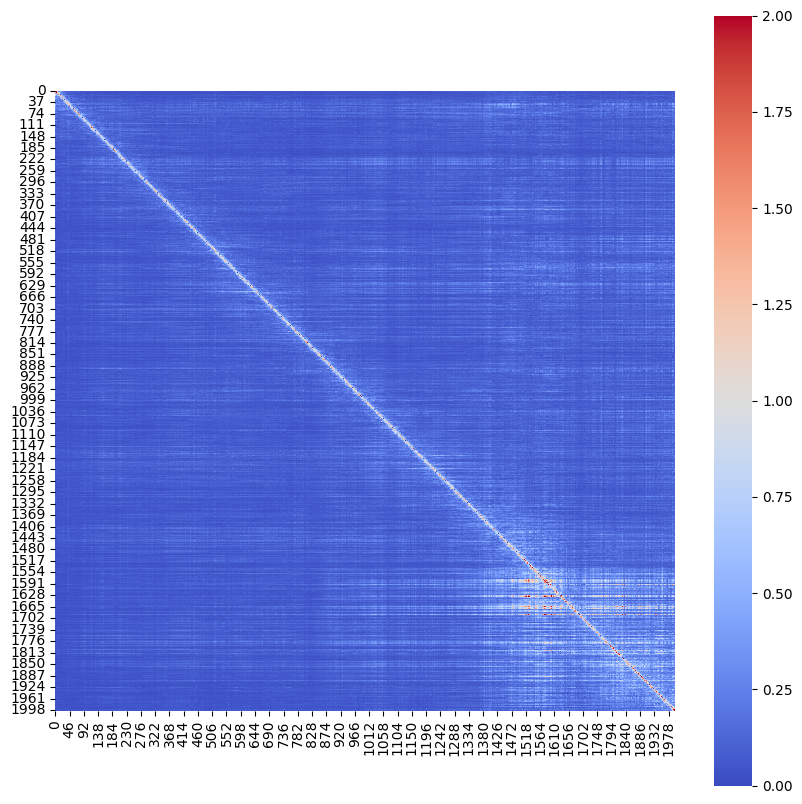

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_map_with_seq(matrix, dna_sequence,  plot_size=10, vmax=5, tick_label_fontsize=8):

    fig, ax = plt.subplots(figsize=(plot_size, plot_size))
    
   
    sns.heatmap(matrix, cmap='coolwarm', vmax=vmax, ax=ax, 
                xticklabels=False, yticklabels=False)  
    ax.set_aspect('equal')

    tick_positions = np.arange(len(dna_sequence)) + 0.5 # Center the ticks

    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(list(dna_sequence), fontsize=tick_label_fontsize, rotation=0)
    ax.set_yticklabels(list(dna_sequence), fontsize=tick_label_fontsize)

    plt.show()
    
def plot_map(matrix, vmax=None, display_values=False, annot_size=8, fig_size=10):
   
    plt.figure(figsize=(fig_size, fig_size))

    ax = sns.heatmap(matrix, cmap="coolwarm", vmax=vmax, annot=display_values, 
                     fmt=".2f", annot_kws={"size": annot_size})

    ax.set_aspect('equal')

    plt.show()

plot_map(dep_map, vmax=2)